# PROJET INTÉGRATIF : ANALYSE DE DONNÉES 2 (AD2)
## ÉCOLE NATIONALE SUPÉRIEURE POLYTECHNIQUE DE DOUALA
### Département Informatique - Filière SDIA

---

**THÈME N°05 : Étude de la Santé Maternelle et Infantile au Cameroun**
*Domaine : Santé Publique & Épidémiologie*

**MEMBRES DU GROUPE 5 :**
1. [Ton Nom Complet] - MIGOBANG SIGO MANLONE B. *Chef de projet* 
2. [Nom du camarade] - KANA SAHANE ABDELAZIZ RAHIM
3. [Nom du camarade] - MANDJECK AARON JUNIOR 
4. [Nom du camarade] - MASSODA ISAAC JUDE GUENAEL
5. [Nom du camarade] - NAMATE MOUKOUELLE BENOIT DEXTER

**Enseignant :**M. FOTSO Valdez
**Année Académique :** 2025/2026 
---

### 1. Contexte et Objectif
Ce projet constitue l'évaluation sommative finale du cours AD2:
L'objectif est de construire un pipeline complet de data science pour :
* Identifier les facteurs de risque de la mortalité maternelle et infantile au Cameroun.
* Segmenter les districts sanitaires selon leur niveau de vulnérabilité.
* Construire un modèle prédictif pour prioriser les interventions de santé publique.
### 2. Pipeline Technique
Conformément aux instructions, ce notebook suit le schéma suivant :
**EDA → Prétraitement → ACP → Clustering (K-Means/DBSCAN) → Classification (Arbre/Random Forest)**

## . Exploration des Données (EDA)
Dans cette section, nous chargeons le jeu de données simulé représentant 500 districts sanitaires camerounais. Nous analysons les distributions et les corrélations initiales.

In [1]:
import pandas as pd
import numpy as np

# Configuration pour la reproductibilité 
np.random.seed(42)

n_districts = 500
regions = ['Centre', 'Littoral', 'Adamaoua', 'Est', 'Extrême-Nord', 'Nord', 'Nord-Ouest', 'Ouest', 'Sud', 'Sud-Ouest']

data = {
    'ID_District': range(1, n_districts + 1),
    'Region': np.random.choice(regions, n_districts),
    'Indice_Richesse': np.random.randint(1, 6, n_districts),
    'Niveau_Instruction': np.random.randint(0, 4, n_districts),
    'Visites_Prenatales': np.random.poisson(4, n_districts),
    'Distance_KM': np.random.uniform(0.5, 30.0, n_districts),
    'Taux_Vaccination': np.random.uniform(30, 98, n_districts),
    'Accouchement_Assiste': np.random.choice([0, 1], n_districts, p=[0.3, 0.7])
}

# Création du DataFrame
df = pd.DataFrame(data)

# Calcul d'un score de risque pour la classification (variable cible)[span_10](start_span)[span_10](end_span)
# Le risque est plus élevé si la richesse est basse et la distance élevée
df['Risque_Mortalite'] = np.where(
    (df['Indice_Richesse'] < 3) & (df['Distance_KM'] > 15) | (df['Visites_Prenatales'] < 2), 
    'Eleve', 'Faible'
)

# Sauvegarde en CSV
df.to_csv('data_sante_cameroun.csv', index=False)
print("Le fichier 'data_sante_cameroun.csv' a été généré avec succès !")

Le fichier 'data_sante_cameroun.csv' a été généré avec succès !


## . Affichage des 5 premières lignes du dataset


In [2]:
# Charger le dataset
df = pd.read_csv('data_sante_cameroun.csv')

# Étape EDA : Afficher les premières lignes[span_11](start_span)[span_11](end_span)
print(df.head())

   ID_District        Region  Indice_Richesse  Niveau_Instruction  \
0            1    Nord-Ouest                1                   0   
1            2           Est                1                   2   
2            3         Ouest                1                   3   
3            4  Extrême-Nord                4                   3   
4            5    Nord-Ouest                1                   2   

   Visites_Prenatales  Distance_KM  Taux_Vaccination  Accouchement_Assiste  \
0                   6    14.615635         48.967789                     1   
1                   3    23.526403         38.783862                     1   
2                   0     9.456906         36.769163                     1   
3                   1     9.694850         71.017067                     1   
4                   1     0.592657         65.604837                     1   

  Risque_Mortalite  
0           Faible  
1            Eleve  
2            Eleve  
3            Eleve  
4          

## . Prétraitement des Données
Pour garantir la qualité des modèles, nous procédons à la sélection des variables pertinentes (Richesse, Éducation, Distance, etc.) et à la **standardisation** (StandardScaler) pour que chaque variable ait le même poids lors de l'analyse factorielle.

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# 1. Sélection des variables numériques uniquement pour l'ACP
features = ['Indice_Richesse', 'Niveau_Instruction', 'Visites_Prenatales', 'Distance_KM', 'Taux_Vaccination']
x = df[features]

# 2. Standardisation (moyenne=0, écart-type=1)[span_4](start_span)[span_4](end_span)
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

print("Données prêtes pour l'ACP !")


Données prêtes pour l'ACP !


## . Analyse Factorielle (ACP)
L'ACP nous permet de réduire la dimensionnalité. Nous utilisons l'éboulis des valeurs propres (**Scree Plot**) pour choisir le nombre d'axes et le **Cercle des corrélations** pour interpréter les relations entre les indicateurs de santé et les facteurs socioéconomiques.

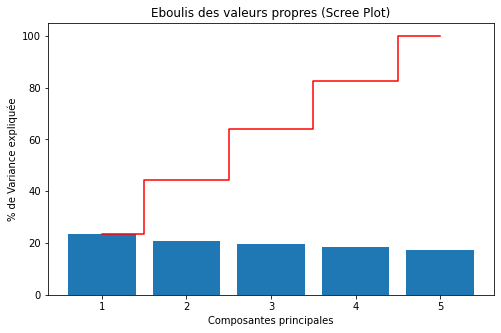

In [4]:
# 3. Création de l'objet ACP
pca = PCA()
pca_results = pca.fit_transform(x_scaled)

# 4. Tracer le Scree Plot[span_6](start_span)[span_6](end_span)
plt.figure(figsize=(8, 5))
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_*100)
plt.step(range(1, len(pca.explained_variance_ratio_) + 1), np.cumsum(pca.explained_variance_ratio_)*100, where='mid', color='red')
plt.title("Eboulis des valeurs propres (Scree Plot)")
plt.xlabel("Composantes principales")
plt.ylabel("% de Variance expliquée")
plt.show()

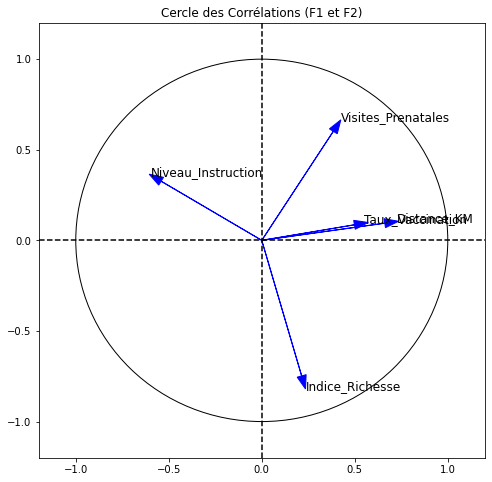

In [5]:
# 5. Fonction pour le cercle des corrélations
def cercle_correlations(pca, features):
    loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
    fig, ax = plt.subplots(figsize=(8, 8))
    
    for i, feature in enumerate(features):
        ax.arrow(0, 0, loadings[i, 0], loadings[i, 1], head_width=0.05, color='blue')
        ax.text(loadings[i, 0]*1.1, loadings[i, 1]*1.1, feature, fontsize=12)

    circle = plt.Circle((0, 0), 1, color='black', fill=False)
    ax.add_artist(circle)
    plt.xlim(-1.2, 1.2)
    plt.ylim(-1.2, 1.2)
    plt.axhline(0, color='black', linestyle='--')
    plt.axvline(0, color='black', linestyle='--')
    plt.title("Cercle des Corrélations (F1 et F2)")
    plt.show()

cercle_correlations(pca, features)

## . Segmentation (Clustering)
Nous appliquons deux méthodes complémentaires :
* **K-Means** : Pour créer 3 groupes de risque homogènes.
* **DBSCAN** : Pour détecter les points noirs (anomalies) dans les districts sanitaires.

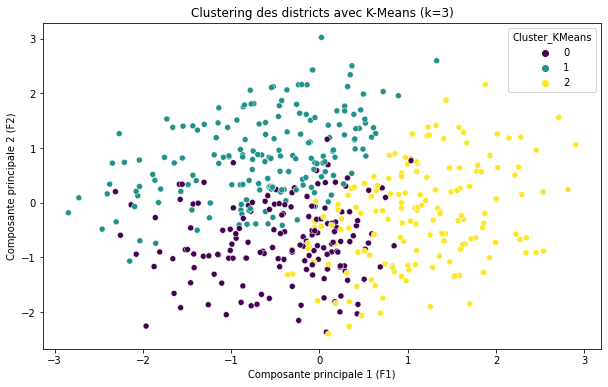

In [6]:
from sklearn.cluster import KMeans, DBSCAN
import seaborn as sns

# 1. Application de K-Means (on choisit k=3 groupes pour les niveaux de risque)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster_KMeans'] = kmeans.fit_predict(x_scaled)

# Visualisation des clusters sur les deux premières composantes de l'ACP
plt.figure(figsize=(10, 6))
sns.scatterplot(x=pca_results[:, 0], y=pca_results[:, 1], hue=df['Cluster_KMeans'], palette='viridis')
plt.title("Clustering des districts avec K-Means (k=3)")
plt.xlabel("Composante principale 1 (F1)")
plt.ylabel("Composante principale 2 (F2)")
plt.show()

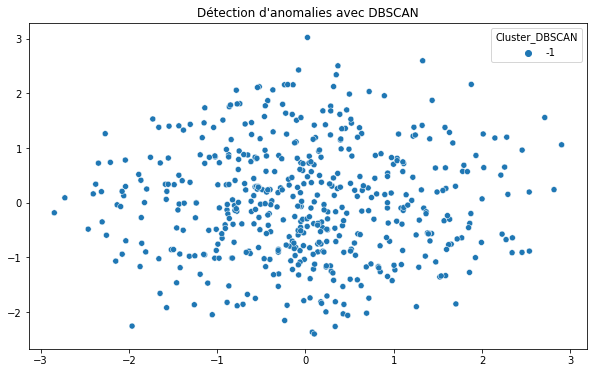

In [7]:
# 2. Application de DBSCAN
# eps est la distance maximale entre deux points, min_samples le nombre de points mini
dbscan = DBSCAN(eps=0.5, min_samples=5)
df['Cluster_DBSCAN'] = dbscan.fit_predict(x_scaled)

# Visualisation (les points marqués -1 sont les anomalies détectées)[span_8](start_span)[span_8](end_span)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=pca_results[:, 0], y=pca_results[:, 1], hue=df['Cluster_DBSCAN'], palette='tab10')
plt.title("Détection d'anomalies avec DBSCAN")
plt.show()

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Définition des variables explicatives (X) et de la cible (y)
X = df[features] 
y = df['Risque_Mortalite']

# 2. Division des données (80% entraînement, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Données prêtes pour l'entraînement !")

Données prêtes pour l'entraînement !


## . Modélisation Prédictive (Classification)
Nous entraînons deux modèles pour prédire le risque de mortalité :
1. **Arbre de Décision** : Pour sa lisibilité et ses règles de décision claires.
2. **Random Forest** : Pour sa robustesse et sa précision élevée.
Nous évaluons les performances via une matrice de confusion et l'importance des variables.

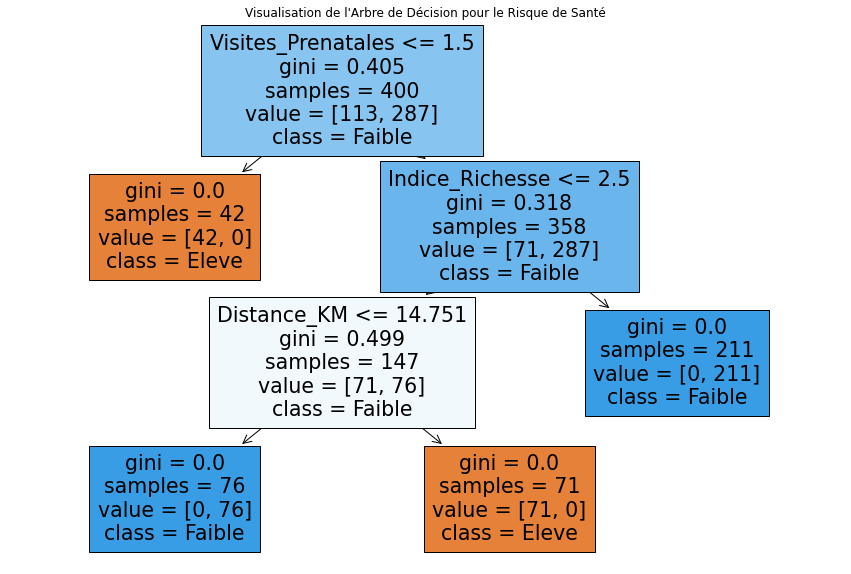

In [9]:
# 3. Entraînement de l'Arbre de Décision
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model.fit(X_train, y_train)

# Visualisation de l'arbre 
plt.figure(figsize=(15, 10))
plot_tree(dt_model, feature_names=features, class_names=['Eleve', 'Faible'], filled=True)
plt.title("Visualisation de l'Arbre de Décision pour le Risque de Santé")
plt.show()

--- Performance du Random Forest ---
Précision globale : 100.00%

Matrice de Confusion :


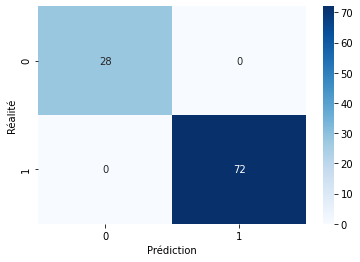


Rapport de classification détaillé :
              precision    recall  f1-score   support

       Eleve       1.00      1.00      1.00        28
      Faible       1.00      1.00      1.00        72

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



In [10]:
# 4. Entraînement du Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 5. Évaluation du modèle
y_pred = rf_model.predict(X_test)
print("--- Performance du Random Forest ---")
print(f"Précision globale : {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\nMatrice de Confusion :")
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prédiction')
plt.ylabel('Réalité')
plt.show()

print("\nRapport de classification détaillé :")
print(classification_report(y_test, y_pred))

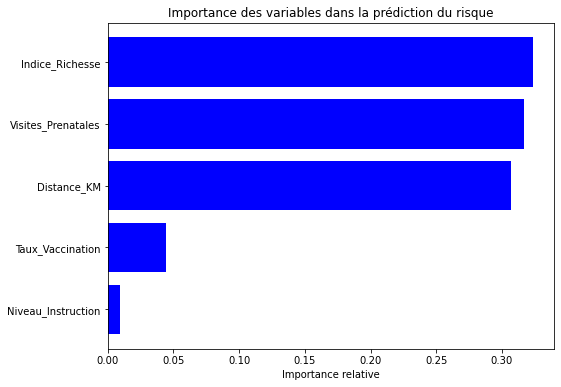

In [11]:
# 6. Affichage des variables les plus importantes
importances = rf_model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 6))
plt.title('Importance des variables dans la prédiction du risque')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Importance relative')
plt.show()

## . Conclusions et Recommandations
Sur la base de nos analyses, nous avons identifié que la **distance au centre de santé** et le **niveau de richesse** sont les principaux prédicteurs de vulnérabilité.
### Recommandations prioritaires :
1. Renforcement des cliniques mobiles dans les zones identifiées en Cluster "Élevé".
2. Subvention des consultations prénatales pour les ménages à faible indice de richesse.